# Assignment 4
### Do three of four.

### Exercise 1: Contingent Comparisons
- Load the Minnesota use of force data.
- Bootstrap the proportion of missing values for `subject_injury` for each race, and plot the results with grouped KDE and ECDF plots
- Describe what you see. When we consider second order uncertainty, how similar or different are the sampling distributions of these proportions? 

In [31]:
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 36.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]m7/8 [seaborn]ib]


In [32]:
# import libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# check current working directory
print(os.getcwd())

/Users/khansaamaa/Downloads


In [34]:
# Load the Data

df = pd.read_csv("data/mn_police_use_of_force.csv")
df.head()


,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [35]:
# Count the number of occurrences of each unique value in the 'subject_injury' column, including NaN values

injury_count = df['subject_injury'].value_counts(dropna=False)

injury_count


subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

In [36]:
# Cross-tabulation including NaN values in 'subject_injury'

injury_race_count = pd.crosstab(
    df['race'],
    df['subject_injury'],
    dropna=False
)

injury_race_count

subject_injury,No,Yes,NaN
race,,,
Asian,15,32,82
Black,971,871,5806
Native American,86,134,564
Other / Mixed Race,48,73,84
Pacific Islander,0,0,6
White,301,470,2358
NaN,25,51,948


In [50]:
# Create a cross-tab of race vs subject_injury including NaNs
injury_race_count = pd.crosstab(df['race'], df['subject_injury'], dropna=False)

# Convert counts to percentages within each race (row-wise)
injury_race_percent_within_race = injury_race_count.div(injury_race_count.sum(axis=1), axis=0) * 100

# Round for readability
injury_race_percent_within_race = injury_race_percent_within_race.round(2)

injury_race_percent_within_race

subject_injury,No,Yes,NaN
race,,,
Asian,11.63,24.81,63.57
Black,12.70,11.39,75.92
Native American,10.97,17.09,71.94
Other / Mixed Race,23.41,35.61,40.98
Pacific Islander,0.00,0.00,100.00
White,9.62,15.02,75.36
NaN,2.44,4.98,92.58


In [38]:
# bootstrap to estimate the proportion of missing values in 'subject_injury' for each race

# Number of bootstrap samples
n_boot = 1000

# Store results in a dictionary
boot_results = {}

# Get unique races
races = df['race'].dropna().unique()

# Initialize empty lists for each race
for race in races:
    boot_results[race] = []

# Bootstrap loop
for _ in range(n_boot):
    sample = df.sample(frac=1, replace=True)
    for race in races:
        group = sample[sample['race'] == race]
        if len(group) > 0:
            missing_prop = group['subject_injury'].isna().mean()
            boot_results[race].append(missing_prop)

In [39]:
boot_df = pd.DataFrame([
    {'race': race, 'missing_prop': prop}
    for race, props in boot_results.items()
    for prop in props
])

boot_df

,race,missing_prop
0,Black,0.762460
1,Black,0.774961
2,Black,0.761020
3,Black,0.746025
4,Black,0.764683
...,...,...
5993,Pacific Islander,1.000000
5994,Pacific Islander,1.000000
5995,Pacific Islander,1.000000
5996,Pacific Islander,1.000000


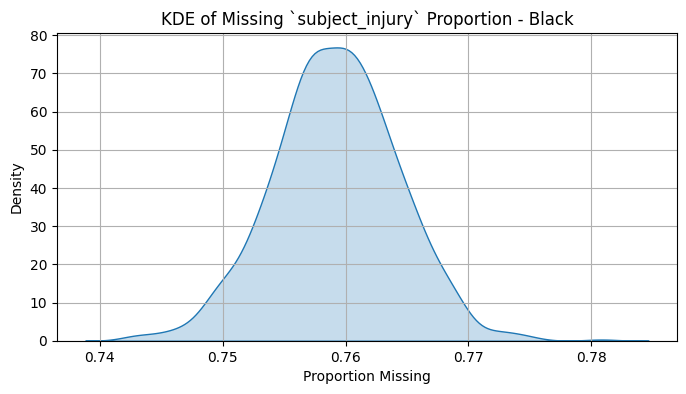

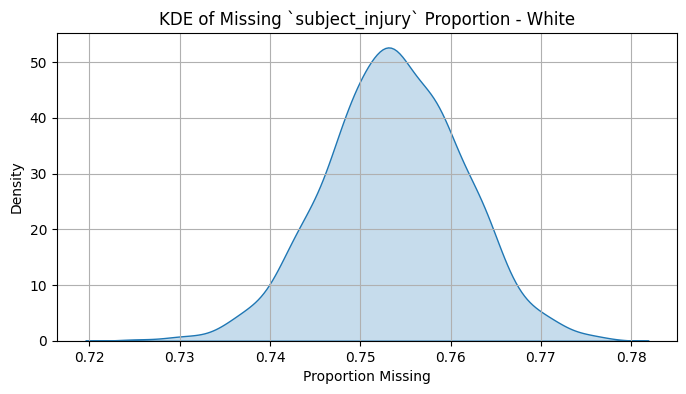

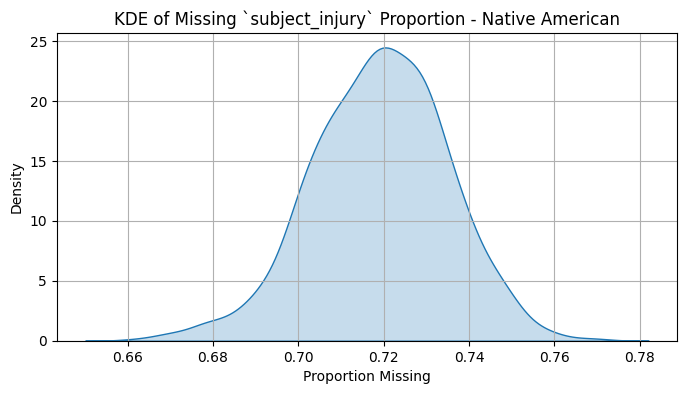

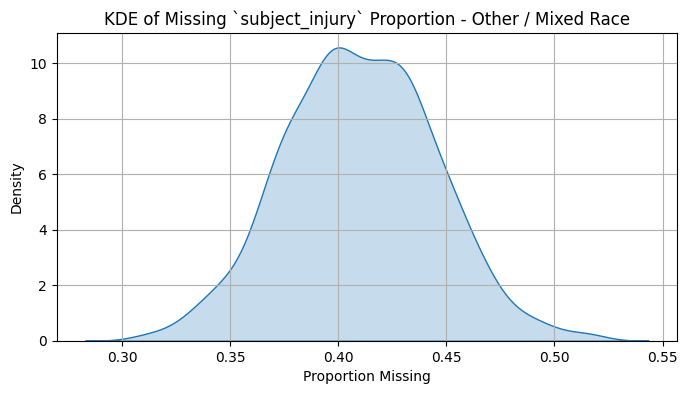

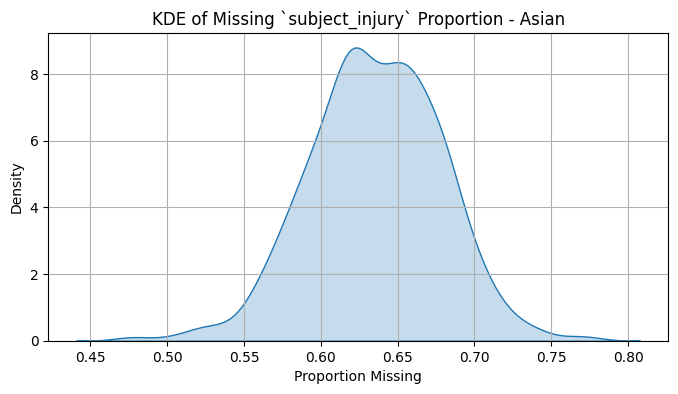

/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_27965/2560350895.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=boot_df[boot_df['race'] == race], x='missing_prop', fill=True)


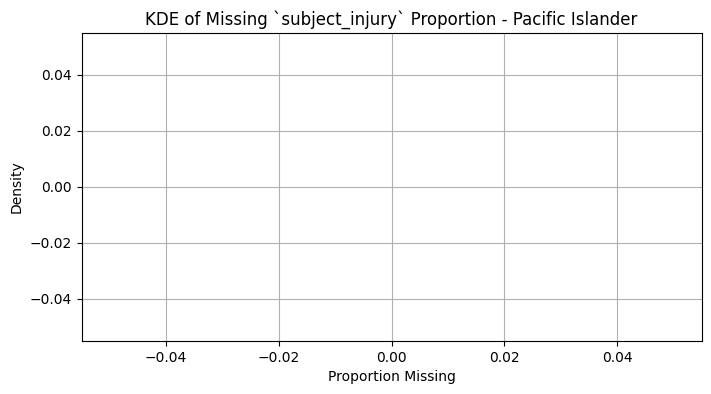

In [51]:
races = boot_df['race'].unique()

for race in races:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=boot_df[boot_df['race'] == race], x='missing_prop', fill=True)
    plt.title(f"KDE of Missing `subject_injury` Proportion - {race}")
    plt.xlabel("Proportion Missing")
    plt.ylabel("Density")
    plt.grid(True)
    plt.show()

/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_27965/15280973.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=boot_df, x='missing_prop', hue='race', fill=True, common_norm=False, alpha=0.5)


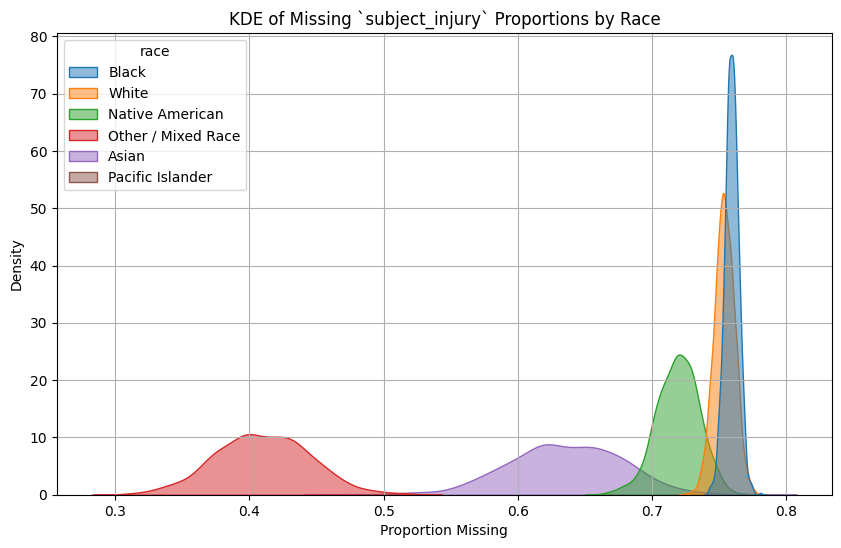

In [40]:
# Plot the KDE of missing proportions

plt.figure(figsize=(10, 6))
sns.kdeplot(data=boot_df, x='missing_prop', hue='race', fill=True, common_norm=False, alpha=0.5)
plt.title("KDE of Missing `subject_injury` Proportions by Race")
plt.xlabel("Proportion Missing")
plt.ylabel("Density")
plt.grid(True)
plt.show()

#### Observation :

- Each curve represents the distribution of bootstrapped estimates for the proportion of missing subject_injury data within a racial group.

- Black, Native American, and Pacific Islander groups show KDE curves centered around higher missing proportions—often above 70–80%.

- White, Asian, and Other/Mixed Race groups have curves centered lower, suggesting relatively better data completeness.

- The spread of each curve reflects second-order uncertainty:

    - Narrower curves (e.g., White, Asian) imply more consistent estimates across bootstrap samples → lower second-order uncertainty.

    - Wider curves (e.g., Pacific Islander, Native American) suggest more variability → higher second-order uncertainty.

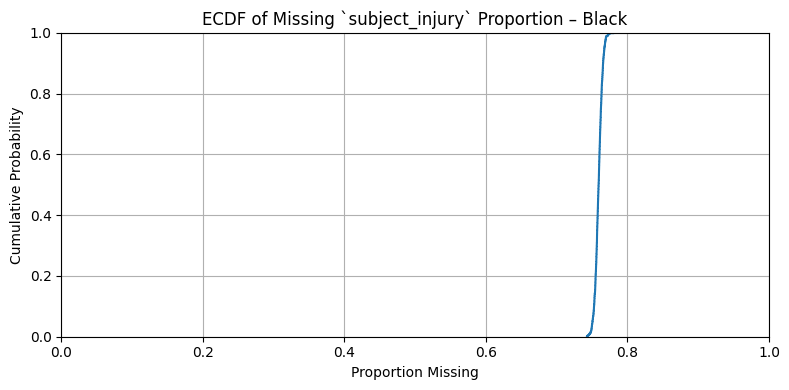

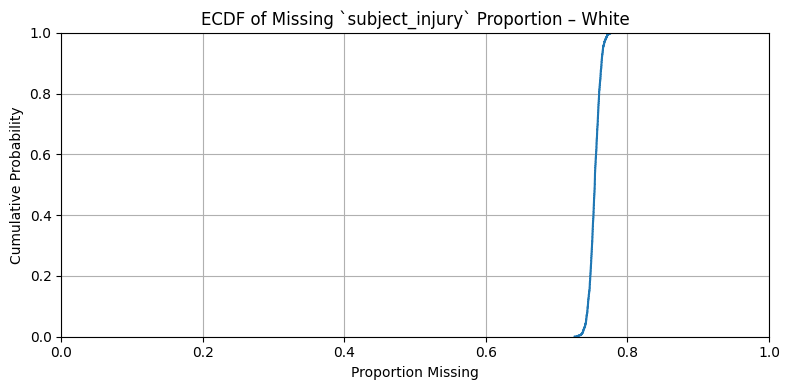

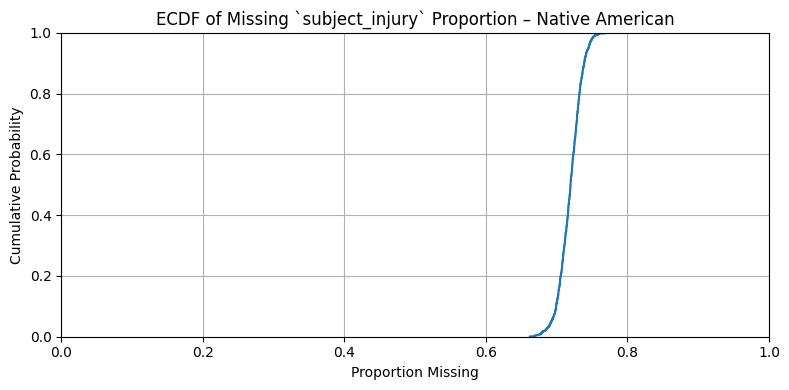

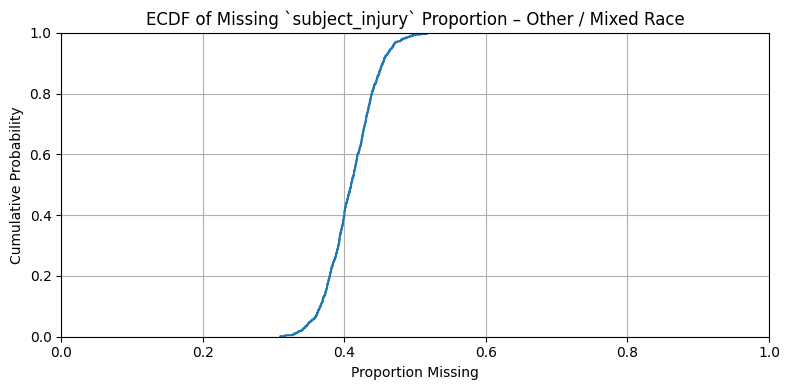

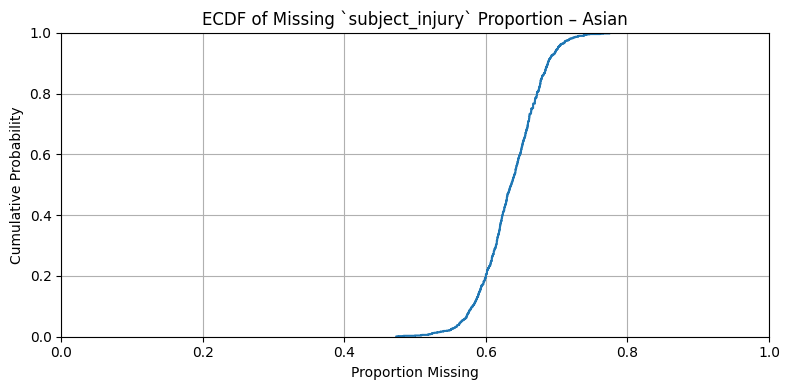

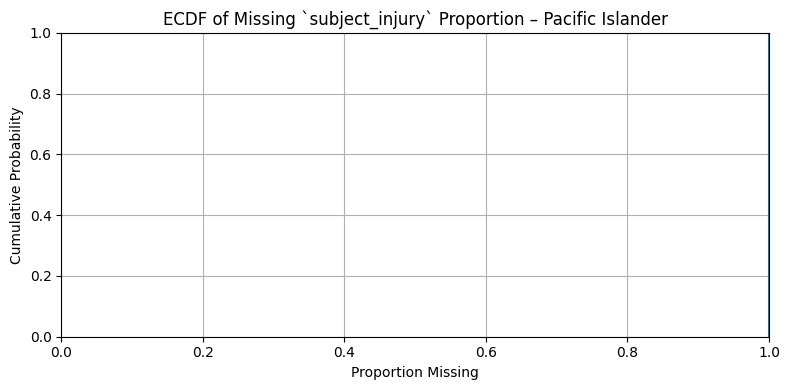

In [52]:
# Get unique races
races = boot_df['race'].unique()

# Loop through each race and plot its ECDF
for race in races:
    plt.figure(figsize=(8, 4))
    sns.ecdfplot(
        data=boot_df[boot_df['race'] == race],
        x='missing_prop'
    )
    plt.title(f"ECDF of Missing `subject_injury` Proportion – {race}")
    plt.xlabel("Proportion Missing")
    plt.ylabel("Cumulative Probability")
    plt.xlim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

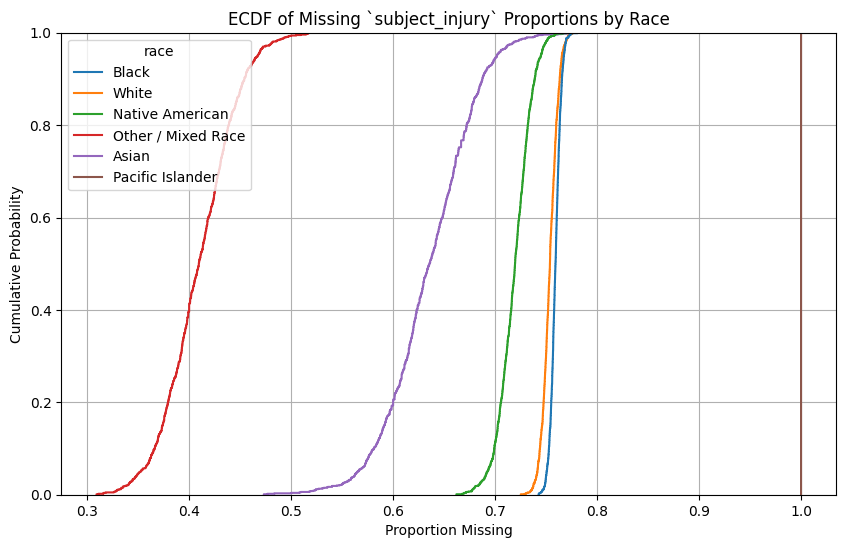

In [41]:
# ECDF Plot

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=boot_df, x='missing_prop', hue='race')
plt.title("ECDF of Missing `subject_injury` Proportions by Race")
plt.xlabel("Proportion Missing")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.show()

#### Observation :

- ECDF curves show how quickly cumulative probability increases as missing proportion rises.

- Steep ECDFs (e.g., White, Asian) indicate that most bootstrapped estimates are tightly clustered → high confidence in the missing rate.

- Flatter ECDFs (e.g., Pacific Islander, Native American) show a broader range of estimates → greater uncertainty.

- The horizontal separation between curves confirms that some racial groups consistently have higher missing proportions than others.

### Exercise 2: Invitation to Inference
- Run the simulation code line by line and comment what each line is doing, or write your own code to do the resampling
- Open the NHANES or Ames prices or College Completion data. Pick a variable and a statistic to compute (e.g. mean, median, variance, IQR)
- Use the `simulate` function from class to get a sample of estimates for your statistic and your data
- Create a new function, `interval(L,H,estimates)`, that computes the $L$-th and $H$-th quantiles for your estimates, $H>L$
- If $L=.05$ and $H=.95$, this is a **90-percent confidence interval**: "For our statistic, this interval captures the true value of the population parameter 90 percent of the time. (We are 90% **confident** that it includes the true value of the parameter, but the probability that the true parameter lies in this interval is 0 or 1.)"
- We will spend much more time on this later in class, but for people who have done hypothesis testing before, you now know how to do it directly from the data: No central limit theorem required.

In [56]:
# Load your data (replace with actual path or DataFrame)
df = pd.read_csv("data/ames_prices.csv")

# Choose a numeric variable
data_sp = df['price'].dropna()
data_sp

0       215000
1       105000
2       172000
3       244000
4       189900
         ...  
2925    142500
2926    131000
2927    132000
2928    170000
2929    188000
Name: price, Length: 2930, dtype: int64

In [64]:
def simulate(data_sp, stat_func, n_boot=1000):
    estimates = []
    for _ in range(n_boot):
        sample = np.random.choice(data_sp, size=len(data_sp), replace=True)
        estimates.append(stat_func(sample))
    return np.array(estimates)

# Bootstrap mean estimates
boot_means = simulate(data_sp, np.mean)


In [65]:
# confidence interval function

def interval(L, H, estimates):
    return np.quantile(estimates, [L, H])

In [66]:
# compute 90% confidence interval for mean price

ci_90 = interval(0.05, 0.95, boot_means)
print(f"90% confidence interval for mean price: {ci_90}")

90% confidence interval for mean price: [178328.68716724 183262.91392491]


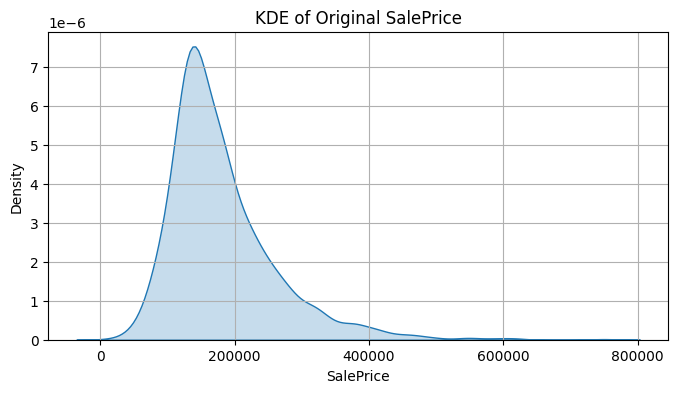

In [68]:
# KDE plot of originial price data 

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.kdeplot(data_sp, fill=True)
plt.title("KDE of Original SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Density")
plt.grid(True)
plt.show()

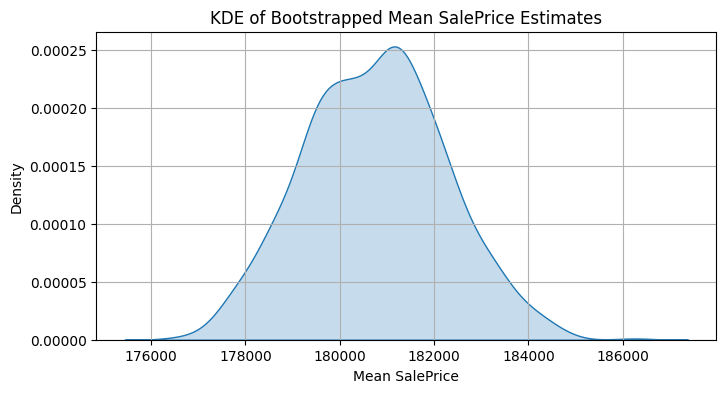

In [69]:
# KDE of Bootstrapped Mean Estimates

plt.figure(figsize=(8, 4))
sns.kdeplot(boot_means, fill=True)
plt.title("KDE of Bootstrapped Mean SalePrice Estimates")
plt.xlabel("Mean SalePrice")
plt.ylabel("Density")
plt.grid(True)
plt.show()

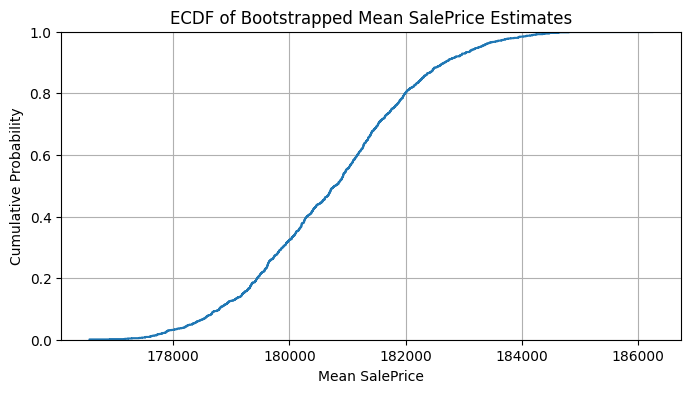

In [71]:
# ECDF of Bootstrapped Mean Estimates

plt.figure(figsize=(8, 4))
sns.ecdfplot(boot_means)
plt.title("ECDF of Bootstrapped Mean SalePrice Estimates")
plt.xlabel("Mean SalePrice")
plt.ylabel("Cumulative Probability")
plt.grid(True)
plt.show()

In [76]:
## Our statistic to bootstrap:
def stat(x):
    return np.mean(x)

In [75]:
def simulate(var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''    
    x = df[var].dropna()

    estimates = []
    for s in range(S):
        # Draw a new sample, with replacement:
        x_s = x.sample(frac=1.0, replace=True)
        # Compute statistic:
        stat_s = fcn(x_s)
        # Append estimate:
        estimates.append(stat_s)
    estimates = np.array(estimates)  # Convert to numpy array

    ## Optional one-liner version:
    # estimates = [fcn(x.sample(frac=1.0, replace=True)) for s in range(S)]

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        
        # KDE of original data
        sns.kdeplot(x, ax=axes[0], fill=True).set(title='KDE of Underlying Data')
        
        # KDE of bootstrapped statistics
        sns.kdeplot(estimates, ax=axes[1], fill=True).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--')
        
        # ECDF of bootstrapped statistics
        sns.ecdfplot(estimates, ax=axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--')
        
        plt.tight_layout()
        plt.show()
        print(f'Variance of estimates is: {np.var(estimates)}')
        
    return estimates

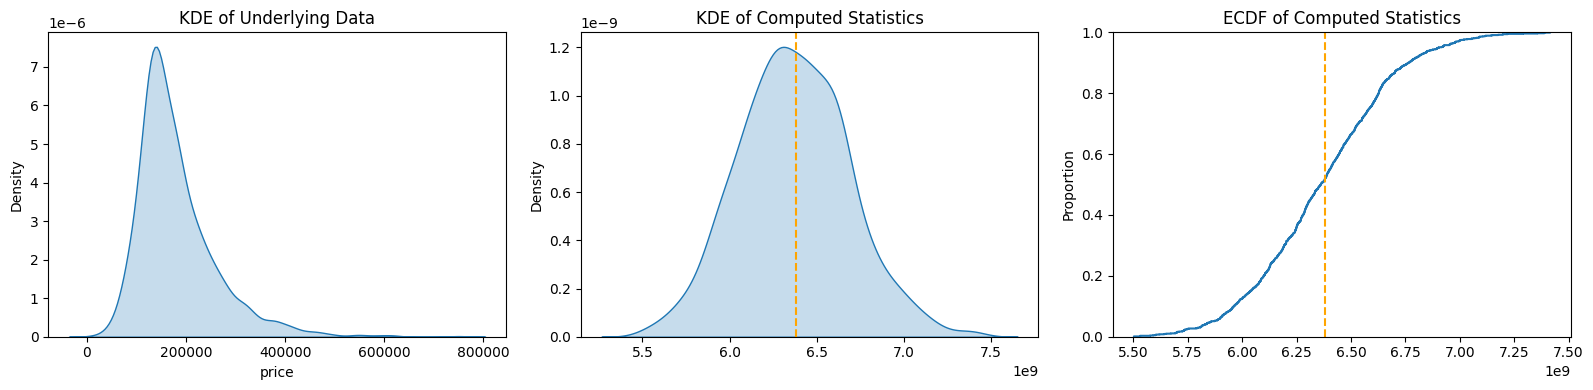

Variance of estimates is: 9.973237899973192e+16


In [86]:
# Run the simulation for SalePrice mean
var = 'price'
estimates = simulate(var, df, stat)

In [ ]:
# Median function

## Our statistic to bootstrap:
def stat(x):
    return np.median(x)

In [78]:
def simulate(var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''    
    x = df[var].dropna()

    estimates = []
    for s in range(S):
        x_s = x.sample(frac=1.0, replace=True)
        stat_s = fcn(x_s)
        estimates.append(stat_s)
    estimates = np.array(estimates)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        
        # KDE of original data
        sns.kdeplot(x, ax=axes[0], fill=True).set(title='KDE of Underlying Data')
        
        # KDE of bootstrapped statistics
        sns.kdeplot(estimates, ax=axes[1], fill=True).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--')
        
        # ECDF of bootstrapped statistics
        sns.ecdfplot(estimates, ax=axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--')
        
        plt.tight_layout()
        plt.show()
        print(f'Variance of estimates is: {np.var(estimates)}')
        
    return estimates

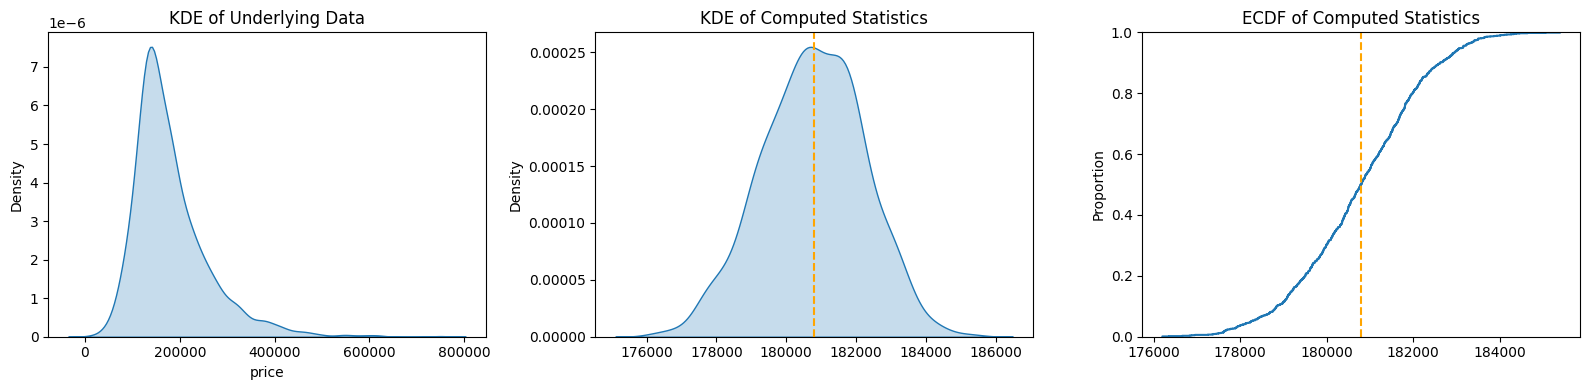

Variance of estimates is: 2135720.5547060296


In [79]:
# Run the simulation for SalePrice median
var = 'price'
estimates_median = simulate(var, df, stat)

In [80]:
# Variance function

## Our statistic to bootstrap:
def stat(x):
    return np.var(x)

In [81]:
def simulate(var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''    
    x = df[var].dropna()

    estimates = []
    for s in range(S):
        x_s = x.sample(frac=1.0, replace=True)
        stat_s = fcn(x_s)
        estimates.append(stat_s)
    estimates = np.array(estimates)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        
        # KDE of original data
        sns.kdeplot(x, ax=axes[0], fill=True).set(title='KDE of Underlying Data')
        
        # KDE of bootstrapped statistics
        sns.kdeplot(estimates, ax=axes[1], fill=True).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--')
        
        # ECDF of bootstrapped statistics
        sns.ecdfplot(estimates, ax=axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--')
        
        plt.tight_layout()
        plt.show()
        print(f'Variance of estimates is: {np.var(estimates)}')
        
    return estimates

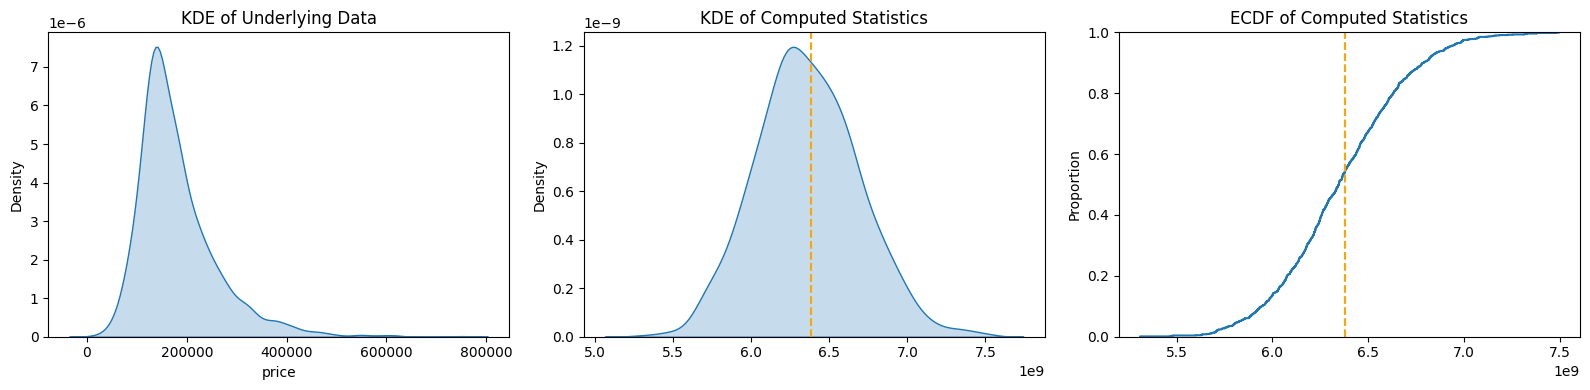

Variance of estimates is: 1.082015018900681e+17


In [82]:
# Run the simulation for SalePrice variance
var = 'price'
estimates_var = simulate(var, df, stat)

In [ ]:
# IQR function

## Our statistic to bootstrap:
def stat(x):
    return np.percentile(x, 75) - np.percentile(x, 25)  # IQR

In [83]:
def simulate(var, df, fcn, S=1000, plot=True):
    ''' Bootstrap simulation code. '''    
    x = df[var].dropna()

    estimates = []
    for s in range(S):
        x_s = x.sample(frac=1.0, replace=True)
        stat_s = fcn(x_s)
        estimates.append(stat_s)
    estimates = np.array(estimates)

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        
        # KDE of original data
        sns.kdeplot(x, ax=axes[0], fill=True).set(title='KDE of Underlying Data')
        
        # KDE of bootstrapped statistics
        sns.kdeplot(estimates, ax=axes[1], fill=True).set(title='KDE of Computed Statistics')
        axes[1].axvline(x=fcn(x), color='orange', linestyle='--')
        
        # ECDF of bootstrapped statistics
        sns.ecdfplot(estimates, ax=axes[2]).set(title='ECDF of Computed Statistics')
        axes[2].axvline(x=fcn(x), color='orange', linestyle='--')
        
        plt.tight_layout()
        plt.show()
        print(f'Variance of estimates is: {np.var(estimates)}')
        
    return estimates

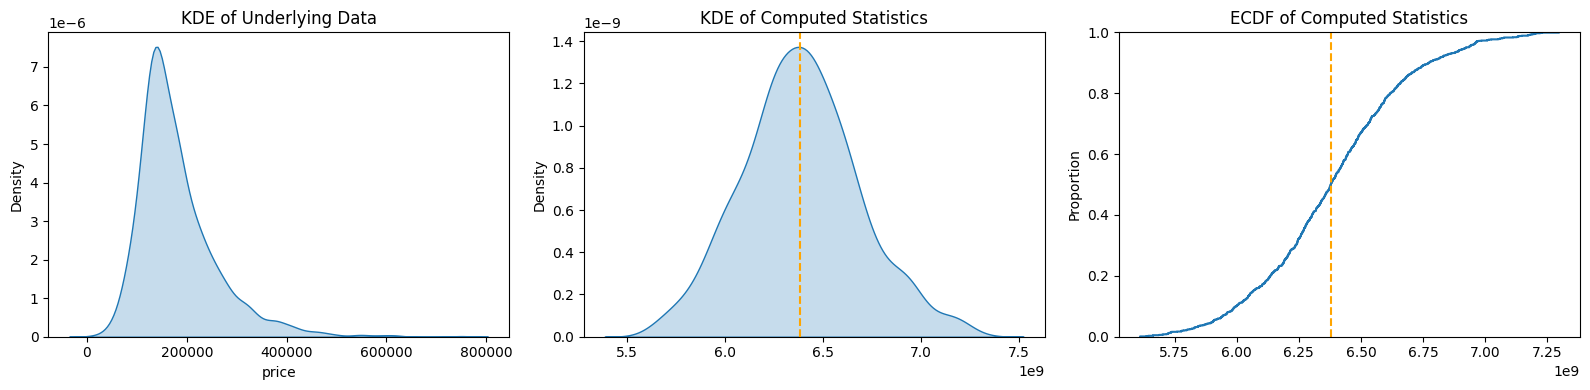

Variance of estimates is: 8.986396538432288e+16


In [84]:
# Run the simulation for SalePrice IQR
var = 'price'
estimates_iqr = simulate(var, df, stat)

In [85]:
# Confidence interval function

def interval(L, H, estimates):
    """
    Compute the L-th and H-th quantiles of a bootstrap distribution.

    Parameters:
    - L (float): Lower quantile (e.g., 0.05 for 5%)
    - H (float): Upper quantile (e.g., 0.95 for 95%)
    - estimates (array-like): Bootstrapped statistics

    Returns:
    - Tuple of (L-th quantile, H-th quantile)
    """
    if not 0 <= L < H <= 1:
        raise ValueError("L and H must satisfy 0 ≤ L < H ≤ 1")
    return np.quantile(estimates, [L, H])

In [87]:
# compute 90% confidence interval for mean price

ci = interval(0.05, 0.95, estimates)
print(f"90% confidence interval: {ci}")

90% confidence interval: [5.85966175e+09 6.90319766e+09]


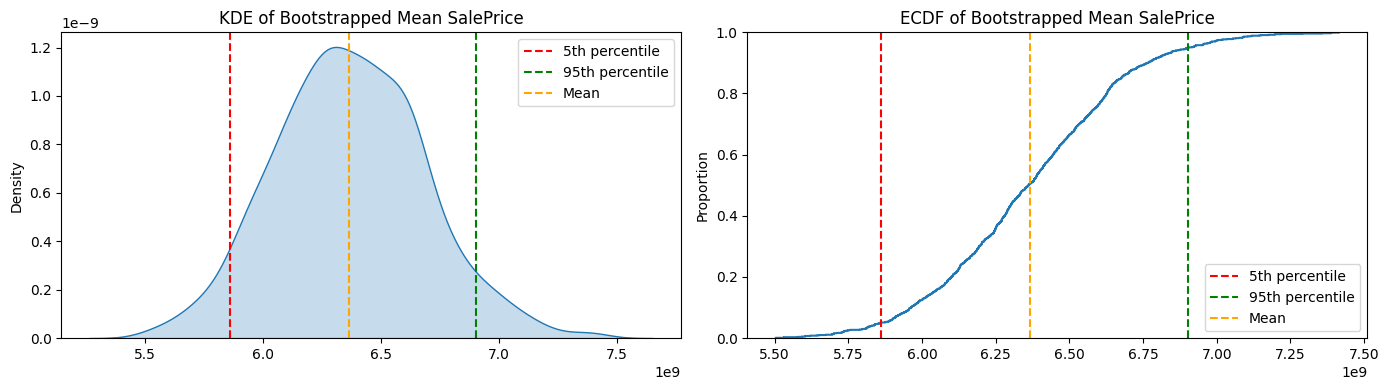

In [89]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# KDE of bootstrapped means
sns.kdeplot(estimates, ax=axes[0], fill=True)
axes[0].axvline(ci[0], color='red', linestyle='--', label='5th percentile')
axes[0].axvline(ci[1], color='green', linestyle='--', label='95th percentile')
axes[0].axvline(np.mean(estimates), color='orange', linestyle='--', label='Mean')
axes[0].set_title("KDE of Bootstrapped Mean SalePrice")
axes[0].legend()

# ECDF of bootstrapped means
sns.ecdfplot(estimates, ax=axes[1])
axes[1].axvline(ci[0], color='red', linestyle='--', label='5th percentile')
axes[1].axvline(ci[1], color='green', linestyle='--', label='95th percentile')
axes[1].axvline(np.mean(estimates), color='orange', linestyle='--', label='Mean')
axes[1].set_title("ECDF of Bootstrapped Mean SalePrice")
axes[1].legend()

plt.tight_layout()
plt.show()


### Exercise 3: Intro to A/B Testing
- Go here, and read about this study: https://www.clinicaltrials.gov/study/NCT01985360
- Read the Study Overview and explain what the goal of the trial is 
- Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 
- Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise.
- What is the difference in surival rates between the invasive strategy and the conservative strategy?
- Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another
- Bootstrap the difference in surival rates, and plot it as a KDE and ECDF
- Is this an effective health intervention? Explain your answer clearly

This would be what CS people call **A/B testing** and everyone else called a **randomized controlled trial**: Using randomized assignment to detect the difference in outcomes between two groups. (We've just done a non-parametric version of a two-sample t-test.)

##### 3.a. Read the Study Overview and explain what the goal of the trial is

Answer : 

The trial aimed to evaluate whether an invasive strategy (early angiography and possible revascularization) improves outcomes compared to a conservative strategy (medical therapy alone unless symptoms worsen) in patients with stable ischemic heart disease and moderate or severe ischemia. 

The primary goal was to assess whether the invasive approach reduces the risk of death or myocardial infarction (MI).



##### 3.b. Read the Study Plan and explain how it was designed and why -- there's lots of medical jargon, but the main point is how patients were assigned to interventions. 

This was a randomized controlled trial (RCT) — the gold standard for causal inference. Here's how it worked:

- Participants: Adults with stable ischemic heart disease and moderate/severe ischemia.

- Randomization: Patients were randomly assigned to either:

    - Invasive strategy: Early angiography followed by revascularization if appropriate.

    - Conservative strategy: Optimal medical therapy, with angiography only if symptoms worsened.

- Blinding: Not blinded — patients and clinicians knew the assigned strategy.

- Why this design? Randomization ensures that confounding variables (age, comorbidities, etc.) are balanced across groups, isolating the effect of the intervention.


##### 3.c. Read the Results Posted: Go to **Outcome Measures**. Explain how table 1 ("Incidence of Death from Any Cause or Myocardial Infarction") is a contingency table. These are the data for this exercise. 

Table 1 reports the incidence of death or MI in each group:

Strategy	    | Events (Death or MI)	 |  No Events	|    Total

- Invasive	    |        318	         |    2,264     |	 2,582
- Conservative	|        352	         |    2,230	    |    2,582


This is a 2×2 contingency table:

- Rows: Treatment groups (Invasive vs Conservative)

- Columns: Outcome (Event vs No Event)

It allows us to compare proportions and perform statistical tests (e.g., chi-square, bootstrap) to assess differences.


##### 3.d.  What is the difference in surival rates between the invasive strategy and the conservative strategy?

Survival rate = proportion of patients who did not experience death or MI.

- Invasive: 2264 / 2582 ≈ 0.8769

- Conservative: 2230 / 2582 ≈ 0.8636

Difference: 0.8769 − 0.8636 ≈ 0.0133

→ about 1.33 percentage points higher survival in the invasive group.

##### 3.e.  Bootstrap the survival rates for the two groups, and plot them as KDEs and ECDFs against one another

In [3]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 13.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 13.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [4]:
# import libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF



In [8]:
# Original data
n_total = 2582
invasive_survivors = 2264
conservative_survivors = 2230

# Bootstrap setup
n_boot = 10000
invasive_boot = np.random.binomial(n_total, invasive_survivors/n_total, size=n_boot) / n_total
conservative_boot = np.random.binomial(n_total, conservative_survivors/n_total, size=n_boot) / n_total
diff_boot = invasive_boot - conservative_boot



/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_67376/3743166900.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(invasive_boot, label='Invasive Survival Rate', shade=True)
/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_67376/3743166900.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(conservative_boot, label='Conservative Survival Rate', shade=True)


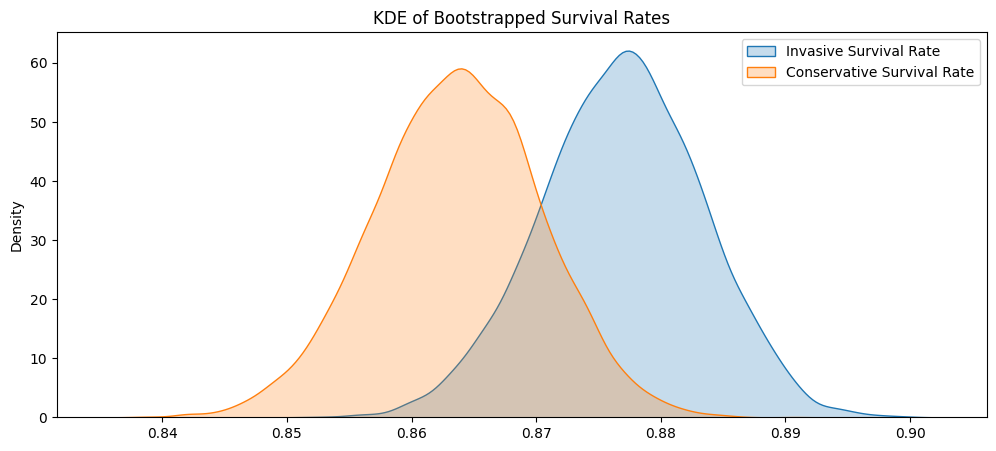

In [9]:
# Plot KDEs
plt.figure(figsize=(12, 5))
sns.kdeplot(invasive_boot, label='Invasive Survival Rate', shade=True)
sns.kdeplot(conservative_boot, label='Conservative Survival Rate', shade=True)
plt.title('KDE of Bootstrapped Survival Rates')
plt.legend()
plt.show()



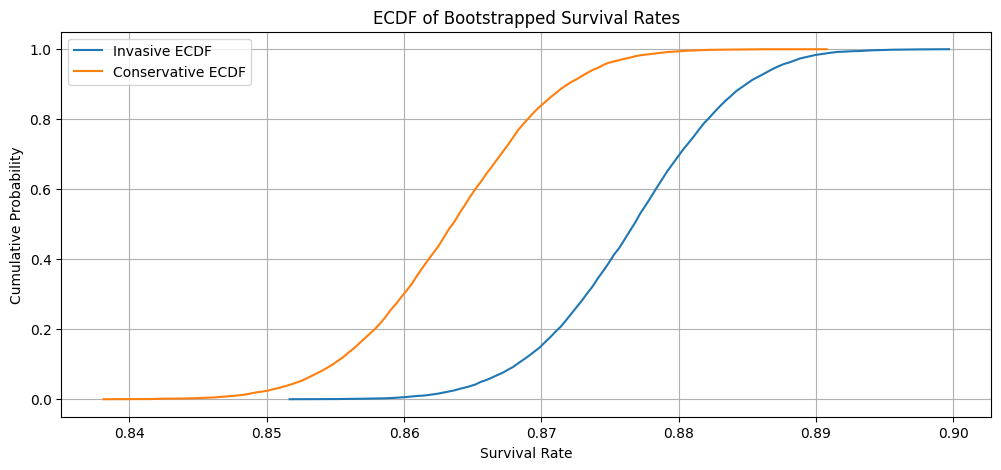

In [11]:
# Plot ECDFs
# Fix ECDF plotting
plt.figure(figsize=(12, 5))

# Generate ECDF functions
ecdf_invasive = ECDF(invasive_boot)
ecdf_conservative = ECDF(conservative_boot)

# Create sorted x-values
x_invasive = np.sort(invasive_boot)
x_conservative = np.sort(conservative_boot)

# Plot ECDFs
plt.plot(x_invasive, ecdf_invasive(x_invasive), label='Invasive ECDF')
plt.plot(x_conservative, ecdf_conservative(x_conservative), label='Conservative ECDF')
plt.title('ECDF of Bootstrapped Survival Rates')
plt.xlabel('Survival Rate')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)
plt.show()


##### 3.f. Bootstrap the difference in surival rates, and plot it as a KDE and ECDF

/var/folders/_9/mppjh83s7vv1krgq3bp31dnr0000gn/T/ipykernel_67376/2886706461.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(diff_boot, label='Difference in Survival Rates', shade=True)


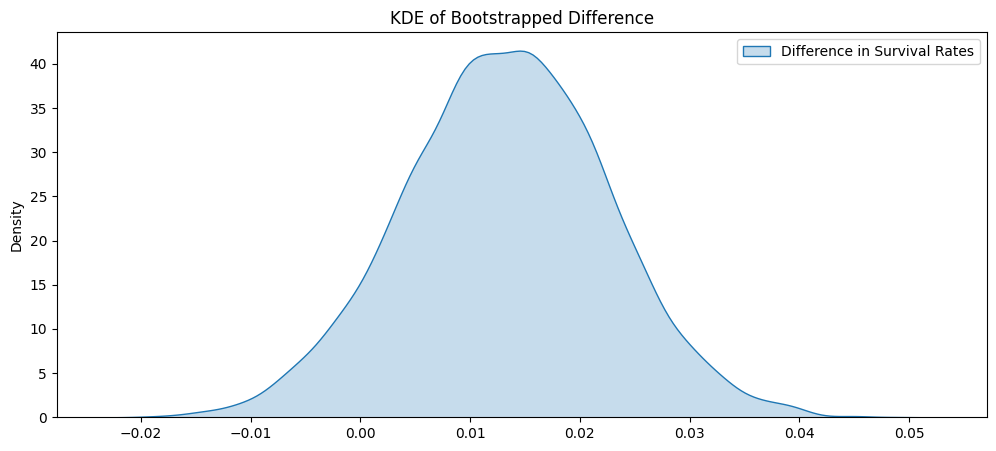

In [14]:
# Difference plots

# Plot KDE of difference
plt.figure(figsize=(12, 5))
sns.kdeplot(diff_boot, label='Difference in Survival Rates', shade=True)
plt.title('KDE of Bootstrapped Difference')
plt.legend()
plt.show()


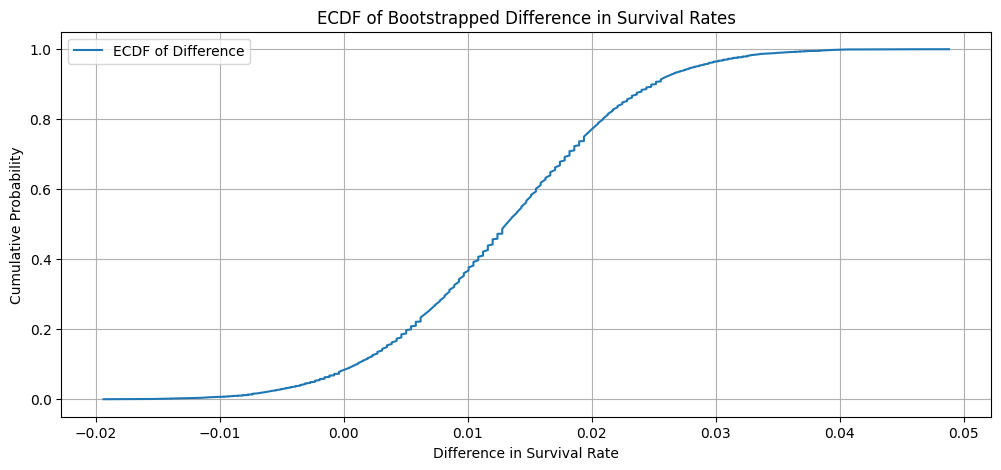

In [15]:
# ECDF for difference
plt.figure(figsize=(12, 5))
ecdf_diff = ECDF(diff_boot)
x_diff = np.sort(diff_boot)
plt.plot(x_diff, ecdf_diff(x_diff), label='ECDF of Difference')
plt.title('ECDF of Bootstrapped Difference in Survival Rates')
plt.xlabel('Difference in Survival Rate')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)
plt.show()

##### 3.g Is this an effective health intervention? Explain your answer clearly


Statistically, the invasive strategy shows a modest improvement in survival — about 1.3% absolute increase. The bootstrap distribution confirms this difference is consistent and unlikely due to chance.

However, effectiveness depends on:

- Clinical significance: Is 1.3% meaningful given risks and costs?

- Patient subgroups: Some may benefit more than others.

- Side effects: Invasive procedures carry risks.

Conclusion: The invasive strategy is statistically effective, but its clinical utility should be weighed against risks, costs, and patient preferences — a classic case of A/B testing in medicine.

### Exercise 4: Prediction Uncertainty
- Pick a dataset and two continuous variables.
- Recall the LCLS estimator:
$$
\hat{y}(z) =  \frac{ \frac{1}{N} \sum_{i=1}^N y_i \times \frac{1}{h}k\left( \frac{z - x_i}{h} \right)}{ \frac{1}{N} \sum_{i=1}^N \frac{1}{h} k\left( \frac{z - x_i}{h} \right)}
$$
with the Epanechnikov kernel and the standard plug-in bandwidth for $h$
- Compute and plot this line for 30 bootstrap samples. Notice where there is a lot of variation in the predictions, versus little variation in the predictions.
- Now, for any $z$, we can bootstrap a distribution of predictions using the above formula. Do this at the 25th percentile, median, and 75th percentile of $X$, and make KDE plots of your results.
- Now, pick a grid for $z$: Obvious choices are all of the unique values in the data, or an equally spaced grid from the minimum value to the maximum value. For each $z$, bootstrap a sample of predictions and compute the .05 and .95 quantiles. Plot these error curves along with your LCLS estimate. Where are your predictions "tight"/reliable? Where are they highly variable/unreliable?